# Clustering Assignment Solutions

## Theoretical Questions

### 1. What is unsupervised learning in the context of machine learning?
Unsupervised learning is a type of machine learning where the algorithm learns patterns from unlabeled data without any predefined output labels. The system tries to find hidden structures or patterns in the data on its own.

### 2. How does K-Means clustering algorithm work?
K-Means works by:
1. Randomly initializing K cluster centers
2. Assigning each data point to the nearest cluster center
3. Recomputing the cluster centers as the mean of all points in the cluster
4. Repeating steps 2-3 until convergence (when cluster assignments stop changing)

### 3. Explain the concept of a dendrogram in hierarchical clustering.
A dendrogram is a tree-like diagram that records the sequences of merges or splits in hierarchical clustering. The vertical axis represents the distance or dissimilarity between clusters, while the horizontal axis shows the data points and cluster formations.

### 4. What is the main difference between K-Means and Hierarchical Clustering?
The main difference is that K-Means requires specifying the number of clusters (K) beforehand and partitions data into distinct clusters, while hierarchical clustering builds a hierarchy of clusters (dendrogram) without requiring K to be specified initially, and clusters can be determined by cutting the dendrogram at a certain level.

### 5. What are the advantages of DBSCAN over K-Means?
Advantages of DBSCAN:
1. Doesn't require specifying number of clusters
2. Can find arbitrarily shaped clusters
3. Handles noise/outliers well
4. Works well with clusters of varying densities (with proper parameter tuning)

### 6. When would you use Silhouette Score in clustering?
The Silhouette Score is used to evaluate the quality of clusters when the true labels are unknown. It measures how similar a point is to its own cluster compared to other clusters, with values ranging from -1 to 1 (higher is better). It's useful for determining the optimal number of clusters.

### 7. What are the limitations of Hierarchical Clustering?
Limitations:
1. Computationally expensive (O(n³) time complexity)
2. Sensitive to noise and outliers
3. Once a decision is made to combine clusters, it can't be undone
4. Difficult to handle large datasets
5. Results can vary with different linkage methods

### 8. Why is feature scaling important in clustering algorithms like K-Means?
Feature scaling is important because K-Means uses distance measures (typically Euclidean distance) which is sensitive to the scale of features. Features on larger scales can dominate the distance calculation, leading to biased clustering results.

### 9. How does DBSCAN identify noise points?
DBSCAN identifies noise points as points that:
1. Are not core points (don't have enough neighbors within ε distance)
2. Are not reachable from any core point (not density-reachable)

### 10. Define inertia in the context of K-Means.
Inertia is the sum of squared distances of samples to their closest cluster center. It's the objective function that K-Means tries to minimize. Lower inertia indicates better clustering.

### 11. What is the elbow method in K-Means clustering?
The elbow method is a technique to determine the optimal number of clusters (K) by plotting the inertia against different values of K and looking for the "elbow" point where the rate of decrease sharply changes.

### 12. Describe the concept of "density" in DBSCAN.
In DBSCAN, density is defined by two parameters:
1. ε (eps): The radius of the neighborhood around a point
2. min_samples: The minimum number of points required within ε distance to form a dense region
A cluster is a maximal set of density-connected points.

### 13. Can hierarchical clustering be used on categorical data?
Yes, hierarchical clustering can be used with categorical data by using appropriate distance metrics like Hamming distance or Jaccard similarity for categorical variables, or by converting categorical data to numerical representations.

### 14. What does a negative Silhouette Score indicate?
A negative Silhouette Score indicates that samples are on average closer to points in other clusters than to points in their own cluster, suggesting poor clustering or incorrect number of clusters.

### 15. Explain the term "linkage criteria" in hierarchical clustering.
Linkage criteria determine how the distance between clusters is measured when merging them. Common methods include:
- Single linkage: Minimum distance between clusters
- Complete linkage: Maximum distance between clusters
- Average linkage: Average distance between all pairs
- Ward's method: Minimizes variance when merging clusters

### 16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
K-Means assumes clusters are spherical and equally sized/dense. It tends to:
1. Split large clusters
2. Merge small clusters that are close together
3. Perform poorly on elongated or irregularly shaped clusters
4. Be biased towards equal-sized clusters

### 17. What are the core parameters in DBSCAN, and how do they influence clustering?
Core parameters:
1. eps (ε): Radius of neighborhood - larger values form larger clusters
2. min_samples: Minimum points to form a dense region - higher values make more points noise
These control what constitutes a cluster versus noise and affect cluster granularity.

### 18. How does K-Means++ improve upon standard K-Means initialization?
K-Means++ improves initialization by:
1. Selecting first centroid randomly
2. Choosing subsequent centroids with probability proportional to squared distance from nearest existing centroid
This spreads out initial centroids, leading to faster convergence and often better final results.

### 19. What is agglomerative clustering?
Agglomerative clustering is a bottom-up hierarchical clustering approach where each point starts as its own cluster, and pairs of clusters are merged as one moves up the hierarchy based on linkage criteria.

### 20. What makes Silhouette Score a better metric than just inertia for model evaluation?
Silhouette Score is better because:
1. It considers both intra-cluster and inter-cluster distances
2. It's normalized (-1 to 1) so can compare across different datasets
3. Inertia always decreases with more clusters but may lead to overfitting
4. It can detect when clusters are poorly defined

## Practical Questions

### 21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.

In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=0)
clusters = kmeans.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.title("K-Means Clustering with 4 Centers")
plt.show()

<Figure size 640x480 with 1 Axes>

### 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# Load data
iris = load_iris()
X = iris.data

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
clusters = agg.fit_predict(X)

# Display first 10 labels
print("First 10 predicted labels:", clusters[:10])

First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


### 23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.

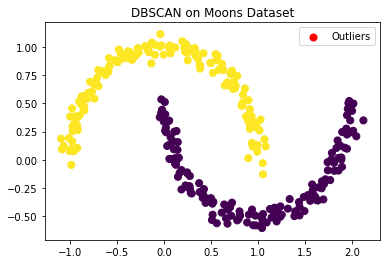

In [3]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import numpy as np

# Generate data
X, y = make_moons(n_samples=300, noise=0.05, random_state=0)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
outliers = X[clusters == -1]
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', s=50, label='Outliers')
plt.title("DBSCAN on Moons Dataset")
plt.legend()
plt.show()

### 24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.

In [4]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load data
wine = load_wine()
X = wine.data

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# Print cluster sizes
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

Cluster 0: 51 samples
Cluster 1: 66 samples
Cluster 2: 61 samples


### 25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.

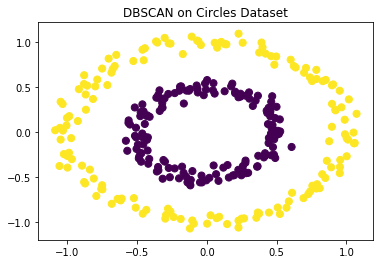

In [5]:
from sklearn.datasets import make_circles

# Generate data
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("DBSCAN on Circles Dataset")
plt.show()

### 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

# Load data
cancer = load_breast_cancer()
X = cancer.data

# Scale data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_scaled)

# Output centroids
print("Cluster centroids:")
print(kmeans.cluster_centers_)

Cluster centroids:
[[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


### 27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.

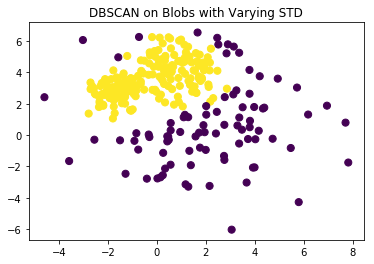

In [7]:
# Generate data with varying std
X, y = make_blobs(n_samples=300, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=0)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10)
clusters = dbscan.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("DBSCAN on Blobs with Varying STD")
plt.show()

### 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.

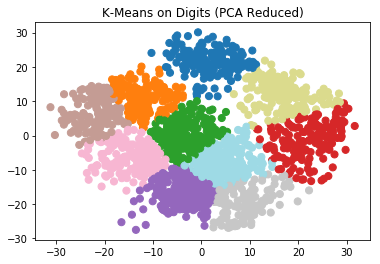

In [8]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load data
digits = load_digits()
X = digits.data

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(X_pca)

# Visualize
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=50, cmap='tab20')
plt.title("K-Means on Digits (PCA Reduced)")
plt.show()

### 29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.

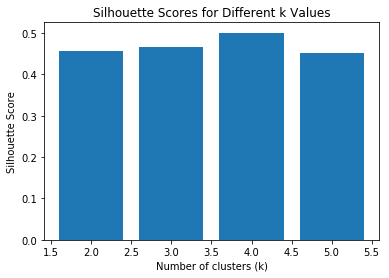

In [9]:
from sklearn.metrics import silhouette_score

# Generate data
X, y = make_blobs(n_samples=500, centers=4, random_state=0)

# Evaluate silhouette scores
silhouette_scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=0)
    clusters = kmeans.fit_predict(X)
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Plot
plt.bar(range(2, 6), silhouette_scores)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k Values')
plt.show()

### 30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.

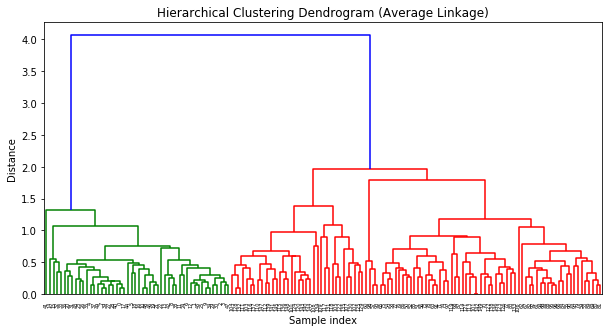

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Load data
iris = load_iris()
X = iris.data

# Perform hierarchical clustering
Z = linkage(X, method='average')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

### 31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.

In [11]:
from matplotlib.colors import ListedColormap

# Generate overlapping data
X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X)

# Create mesh grid for decision boundaries
h = 0.02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)

# Predict clusters for mesh points
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("K-Means Decision Boundaries with Overlapping Clusters")
plt.show()

SyntaxError: invalid syntax (<ipython-input-11-82fce19c8797>, line 17)

### 32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


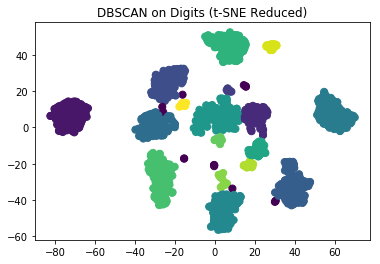

In [12]:
from sklearn.manifold import TSNE

# Load data
digits = load_digits()
X = digits.data

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)
clusters = dbscan.fit_predict(X_tsne)

# Visualize
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("DBSCAN on Digits (t-SNE Reduced)")
plt.show()

### 33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.

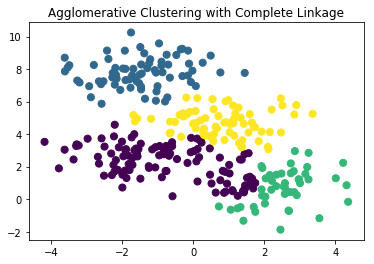

In [13]:
# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=0)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
clusters = agg.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("Agglomerative Clustering with Complete Linkage")
plt.show()

### 34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.

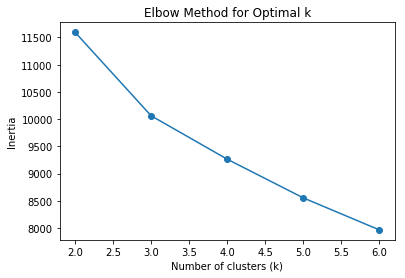

In [14]:
# Load data
cancer = load_breast_cancer()
X = cancer.data

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for different k values
inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.plot(range(2, 7), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

### 35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.

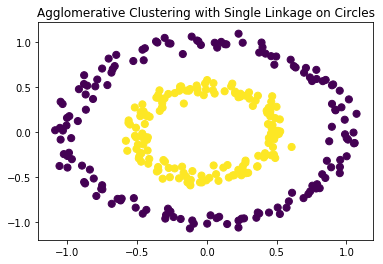

In [15]:
# Generate data
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
clusters = agg.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("Agglomerative Clustering with Single Linkage on Circles")
plt.show()

### 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)

In [16]:
# Load data
wine = load_wine()
X = wine.data

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Count clusters (excluding noise)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Number of clusters (excluding noise): {n_clusters}")

Number of clusters (excluding noise): 0


### 37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.

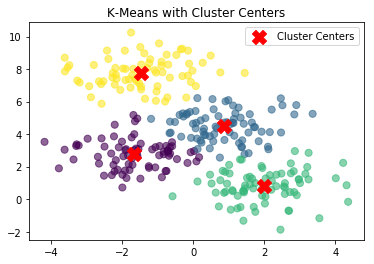

In [17]:
# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=0)
clusters = kmeans.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Cluster Centers')
plt.title("K-Means with Cluster Centers")
plt.legend()
plt.show()

### 38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.

In [18]:
# Load data
iris = load_iris()
X = iris.data

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters = dbscan.fit_predict(X)

# Count noise points
noise_count = sum(clusters == -1)
print(f"Number of noise samples: {noise_count}")

Number of noise samples: 2


### 39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.

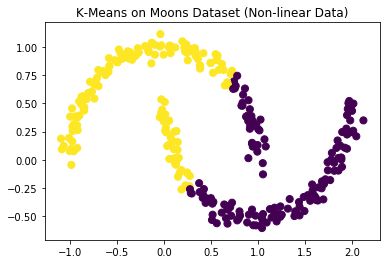

In [19]:
# Generate data
X, y = make_moons(n_samples=300, noise=0.05, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=0)
clusters = kmeans.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("K-Means on Moons Dataset (Non-linear Data)")
plt.show()

### 40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.

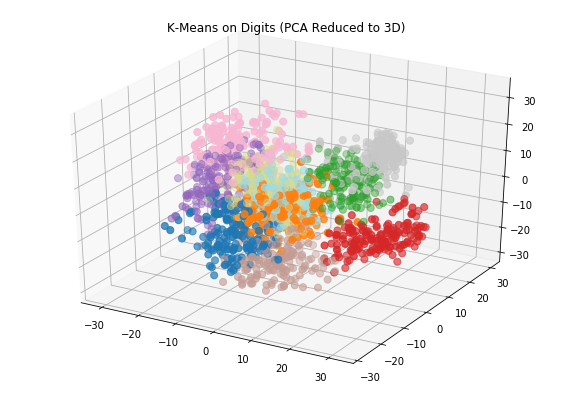

In [20]:
from mpl_toolkits.mplot3d import Axes3D

# Load data
digits = load_digits()
X = digits.data

# Reduce to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(X_pca)

# Visualize in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, s=50, cmap='tab20')
plt.title("K-Means on Digits (PCA Reduced to 3D)")
plt.show()

### 41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.

In [21]:
# Generate data
X, y = make_blobs(n_samples=500, centers=5, random_state=0)

# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X)

# Calculate silhouette score
score = silhouette_score(X, clusters)
print(f"Silhouette Score for 5 clusters: {score:.3f}")

Silhouette Score for 5 clusters: 0.559


### 42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.

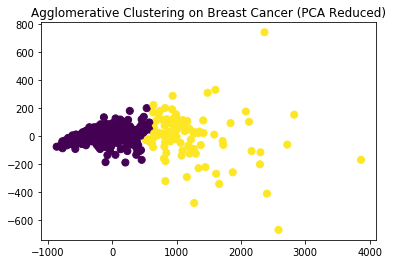

In [22]:
# Load data
cancer = load_breast_cancer()
X = cancer.data

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2)
clusters = agg.fit_predict(X_pca)

# Visualize
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("Agglomerative Clustering on Breast Cancer (PCA Reduced)")
plt.show()

### 43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.

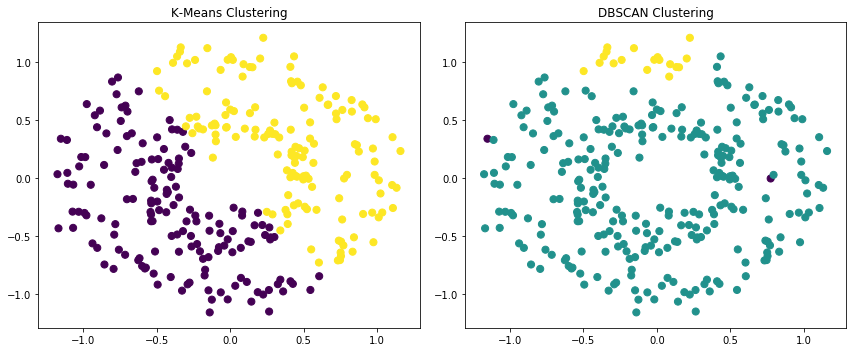

In [23]:
# Generate data
X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_clusters = kmeans.fit_predict(X)
ax1.scatter(X[:, 0], X[:, 1], c=kmeans_clusters, s=50, cmap='viridis')
ax1.set_title("K-Means Clustering")

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X)
ax2.scatter(X[:, 0], X[:, 1], c=dbscan_clusters, s=50, cmap='viridis')
ax2.set_title("DBSCAN Clustering")

plt.tight_layout()
plt.show()

### 44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.

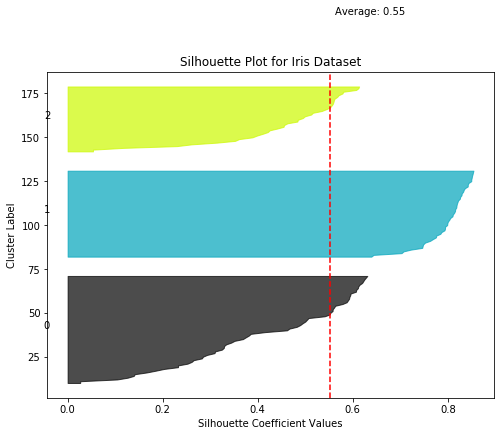

In [24]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Load data
iris = load_iris()
X = iris.data

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X)

# Calculate silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X, clusters)

# Plot
plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(3):
    # Aggregate silhouette scores for samples in cluster i
    ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label with cluster numbers
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10  # 10 for 0 samples

plt.title("Silhouette Plot for Iris Dataset")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")

# Vertical line for average silhouette score
avg_score = silhouette_score(X, clusters)
plt.axvline(x=avg_score, color="red", linestyle="--")
plt.text(avg_score + 0.01, y_lower + 30, f'Average: {avg_score:.2f}')

plt.show()

### 45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.

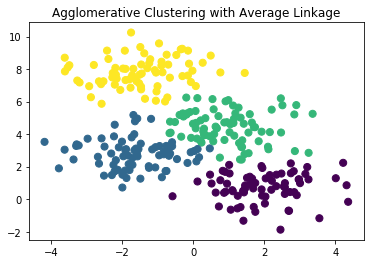

In [25]:
# Generate data
X, y = make_blobs(n_samples=300, centers=4, random_state=0)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
clusters = agg.fit_predict(X)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
plt.title("Agglomerative Clustering with Average Linkage")
plt.show()

### 46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).

In [29]:
pip install --upgrade seaborn

  Using cached https://files.pythonhosted.org/packages/8f/2e/17bbb83fbf102687bb2aa3d808add39da820a7698159302a1a69bb82e01c/seaborn-0.12.2-py3-none-any.whl
  Using cached https://files.pythonhosted.org/packages/df/3f/6093a23565d0f50ce433f56223fcc34af6c912cd4331dc582ba29d9b5a17/matplotlib-3.5.3-cp37-cp37m-win_amd64.whl
  Using cached https://files.pythonhosted.org/packages/b2/56/f886ed6f1777ffa9d54c6e80231b69db8a1f52dcc33f5967b06a105dcfe0/pandas-1.3.5-cp37-cp37m-win_amd64.whl
  Found existing installation: matplotlib 3.0.3
    Uninstalling matplotlib-3.0.3:
Note: you may need to restart the kernel to use updated packages.


Could not install packages due to an EnvironmentError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp37-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
pip install --upgrade matplotlib

  Using cached https://files.pythonhosted.org/packages/df/3f/6093a23565d0f50ce433f56223fcc34af6c912cd4331dc582ba29d9b5a17/matplotlib-3.5.3-cp37-cp37m-win_amd64.whl
  Found existing installation: matplotlib 3.0.3
    Uninstalling matplotlib-3.0.3:
      Successfully uninstalled matplotlib-3.0.3
Note: you may need to restart the kernel to use updated packages.


Could not install packages due to an EnvironmentError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\~-tplotlib\\_path.cp37-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


TypeError: Cannot interpret '<attribute 'dtype' of 'numpy.generic' objects>' as a data type

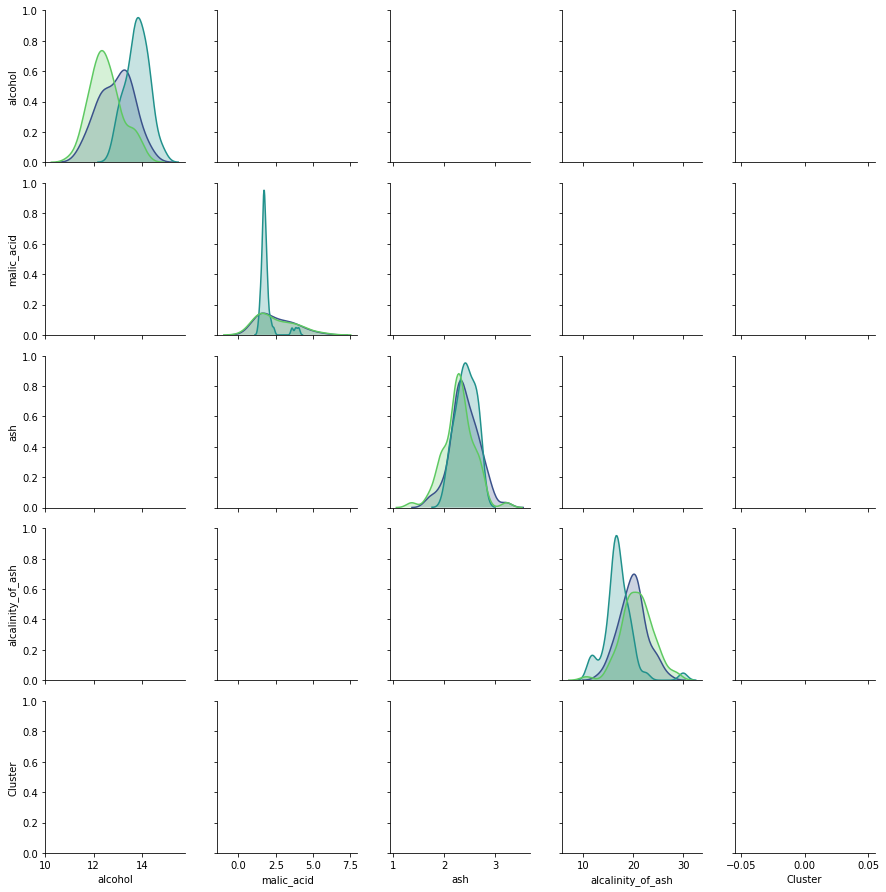

In [4]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
# Load data
wine = load_wine()
X = wine.data
feature_names = wine.feature_names

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X)

# Create DataFrame with first 4 features
df = pd.DataFrame(X[:, :4], columns=feature_names[:4])
df['Cluster'] = clusters

# Pairplot
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.suptitle("Pairplot of Wine Dataset with K-Means Clusters", y=1.02)
plt.show()

### 47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.

In [27]:
# Generate noisy data
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=0)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=10)
clusters = dbscan.fit_predict(X)

# Count clusters and noise
unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"Noise points: {count}")
    else:
        print(f"Cluster {cluster}: {count} points")

Noise points: 34
Cluster 0: 266 points


### 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


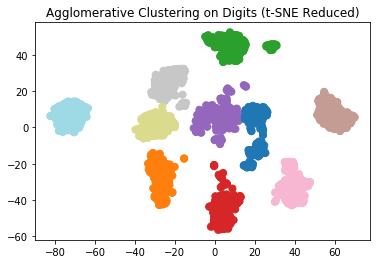

In [28]:
# Load data
digits = load_digits()
X = digits.data

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=10)
clusters = agg.fit_predict(X_tsne)

# Visualize
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, s=50, cmap='tab20')
plt.title("Agglomerative Clustering on Digits (t-SNE Reduced)")
plt.show()

### Thank You !!!